# MEIA Challenge 3 — EDA

Análise exploratória dos datasets de logs Sysmon.

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from preprocessor import parse_csv, make_windows
from detectors import IForestDetector, tag_techniques


## 1. Carregar dados

In [3]:
df = parse_csv(Path('../data/samples/sample_lmd.csv'), dataset='lmd')
print(f'Events: {len(df)}')
print(f'Time range: {df.timestamp.min()} → {df.timestamp.max()}')
df.head()

Events: 24
Time range: 2024-03-01 10:00:01+00:00 → 2024-03-01 10:02:03+00:00


,timestamp,event_id,process_name,process_id,parent_process,target_process,network_dest_ip,network_dest_port,file_path,registry_key,user,command_line
0,2024-03-01 10:00:01+00:00,1,cmd.exe,1234,C:\Windows\explorer.exe,NaN,NaN,NaN,NaN,NaN,DESKTOP\user,cmd.exe /c whoami
1,2024-03-01 10:00:02+00:00,1,powershell.exe,1235,C:\Windows\System32\cmd.exe,NaN,NaN,NaN,NaN,NaN,DESKTOP\user,powershell.exe -NoP -NonI -Exec Bypass -Comman...
2,2024-03-01 10:00:03+00:00,3,powershell.exe,1235,NaN,NaN,192.168.1.100,80.0,NaN,NaN,DESKTOP\user,NaN
3,2024-03-01 10:00:04+00:00,3,powershell.exe,1235,NaN,NaN,10.0.0.50,445.0,NaN,NaN,DESKTOP\user,NaN
4,2024-03-01 10:00:05+00:00,3,net.exe,1236,NaN,NaN,10.0.0.51,445.0,NaN,NaN,DESKTOP\user,NaN


## 2. Distribuição de EventIDs

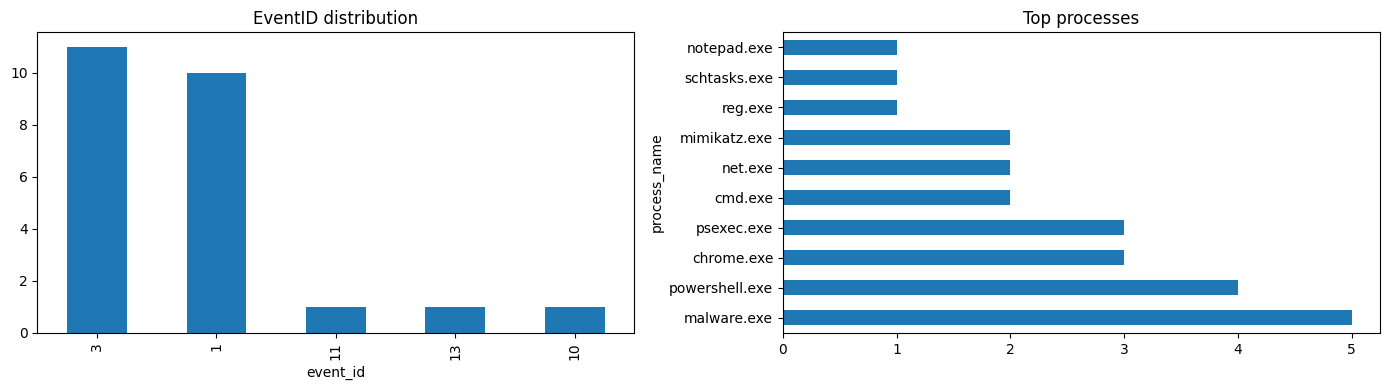

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['event_id'].value_counts().plot(kind='bar', ax=axes[0], title='EventID distribution')
df['process_name'].value_counts().head(15).plot(kind='barh', ax=axes[1], title='Top processes')

plt.tight_layout()
plt.show()

## 3. Windowing e features

In [5]:
windows = list(make_windows(df, window_size_seconds=60))
print(f'Windows: {len(windows)}')

wdf = pd.DataFrame([w.to_dict() for w in windows])
wdf[['event_count', 'suspicious_process_count', 'network_connection_count',
     'powershell_count', 'has_mimikatz', 'has_psexec']].describe()

Windows: 3


,event_count,suspicious_process_count,network_connection_count,powershell_count
count,3.000000,3.000000,3.000000,3.000000
mean,8.000000,4.666667,3.666667,1.333333
std,6.928203,5.033223,2.886751,2.309401
min,4.000000,0.000000,2.000000,0.000000
25%,4.000000,2.000000,2.000000,0.000000
50%,4.000000,4.000000,2.000000,0.000000
75%,10.000000,7.000000,4.500000,2.000000
max,16.000000,10.000000,7.000000,4.000000


## 4. IsolationForest scoring

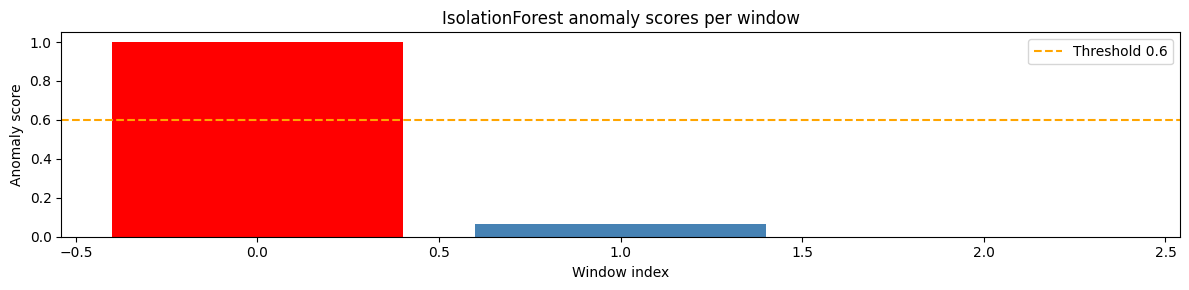

Windows above threshold: 1/3


In [6]:
import numpy as np

X = np.array([w.to_feature_vector() for w in windows])
iforest = IForestDetector()
iforest.fit(X)
scores = iforest.score(X)

wdf['if_score'] = scores

plt.figure(figsize=(12, 3))
plt.bar(range(len(scores)), scores, color=['red' if s > 0.6 else 'steelblue' for s in scores])
plt.axhline(0.6, color='orange', linestyle='--', label='Threshold 0.6')
plt.xlabel('Window index')
plt.ylabel('Anomaly score')
plt.title('IsolationForest anomaly scores per window')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Windows above threshold: {(scores > 0.6).sum()}/{len(scores)}')

## 5. ATT&CK rule tagging

In [7]:
for i, w in enumerate(windows):
    hits = tag_techniques(w.to_dict())
    if hits:
        print(f'Window {i} (score={scores[i]:.2f}):')
        for h in hits:
            print(f'  {h["technique"]} {h["name"]} conf={h["confidence"]}')

Window 0 (score=1.00):
  T1059.001 PowerShell conf=0.7
  T1021.002 SMB/Windows Admin Shares conf=0.6
  T1003 Credential Dumping conf=0.95
Window 2 (score=0.00):
  T1570 Lateral Tool Transfer (PsExec) conf=0.85


## 6. Análise dos resultados do judge (se existirem)

In [ ]:

results_path = Path('../results')
judge_files = list(results_path.rglob('judge_results.json'))

if judge_files:
    with open(sorted(judge_files)[-1]) as f:
        judge_data = json.load(f)

    if not judge_data:
        print('judge_results.json encontrado mas está vazio (0 janelas julgadas).')
        print('Verifica se o threshold está baixo o suficiente para escalarem janelas ao judge.')
    else:
        jdf = pd.DataFrame(judge_data)
        print(f'Judge results: {len(jdf)}')
        cols = [c for c in ['window_start', 'anomaly_score', 'verdict', 'fp_risk'] if c in jdf.columns]
        print(jdf[cols].to_string())
else:
    print('Nenhum ficheiro de judge results encontrado. Corre o pipeline primeiro.')


Judge results: 0


KeyError: "None of [Index(['window_start', 'anomaly_score', 'verdict', 'fp_risk'], dtype='str')] are in the [columns]"